In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

In [2]:
df = pd.read_csv("data/processed/df_with_segment_labels.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


In [3]:
# --- Billing / Value features ---
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'].replace(0, 1))
df['charge_gap'] = df['MonthlyCharges'] - df['avg_monthly_spend']
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# --- Tenure band (categorical) ---
df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['0-12', '12-36', '36+'],
    right=True
)
df['tenure_band'] = df['tenure_band'].astype(str)

# --- Service usage counts (numeric) ---
streamning_services = ['StreamingTV','StreamingMovies']
df['streaming_count'] = ((df[streamning_services] == 'Yes') | (df[streamning_services] == 'yes')).sum(axis=1)

security_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['security_count'] = ((df[security_services] == 'Yes') | (df[security_services] == 'yes')).sum(axis=1) 

df['month_to_month_paperless'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['PaperlessBilling'] == 'Yes')
).astype(int)

df['payment_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)


    # --- Vulnerability / persona flags (numeric) ---
df['no_support_services'] = ((df['TechSupport'] == 'No') &(df['OnlineSecurity'] == 'No')).astype(int)
    
df['is_isolated'] = ((df['Partner'] == 'No') &(df['Dependents'] == 'No')).astype(int)
    
df['fiber_no_security'] = ((df['InternetService'] == 'Fiber optic') &(df['OnlineSecurity'] == 'No')).astype(int)
    
df['no_internet_services'] = (df['InternetService'] == 'No').astype(int)

In [5]:
df.shape

(7032, 34)

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label,avg_monthly_spend,charge_gap,is_high_value,tenure_band,streaming_count,security_count,month_to_month_paperless,payment_electronic_check,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️,29.850000,0.000000,0,0-12,0,1,1,1,1,0,0,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍,55.573529,1.376471,0,12-36,0,2,0,0,0,1,0,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍,54.075000,-0.225000,0,0-12,0,2,1,0,0,1,0,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍,40.905556,1.394444,0,36+,0,3,0,0,0,1,0,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨,75.825000,-5.125000,1,0-12,0,0,1,1,1,1,1,0


In [8]:
X = df.drop(['Churn','segment_label'], axis=1)
y = df['Churn']

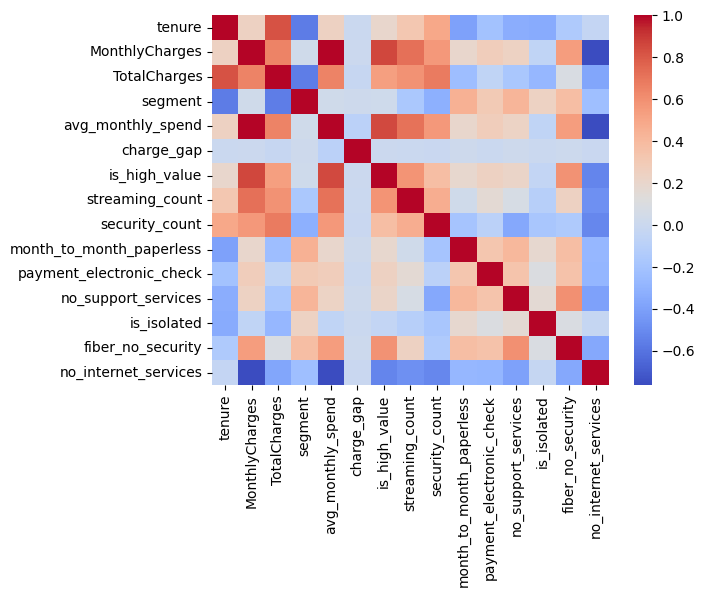

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [9]:
X.shape, y.shape

((7032, 32), (7032,))

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.metrics import roc_auc_score, classification_report, make_scorer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

In [12]:
# Train / Validation / Test split
# 70% train | 15% val | 15% test
# ─────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    # 0.176 of 85% ≈ 15% of total
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Cross-validation object (used in Phase 1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: (4925, 32), Val: (1052, 32), Test: (1055, 32)


In [13]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
cat_cols.append('segment')  # treat segment as categorical
cat_cols = list(set(cat_cols))
num_cols = [c for c in X.columns if c not in cat_cols]

In [14]:
cat_cols,num_cols

(['gender',
  'InternetService',
  'OnlineBackup',
  'PaperlessBilling',
  'Dependents',
  'StreamingTV',
  'SeniorCitizen',
  'MultipleLines',
  'DeviceProtection',
  'TechSupport',
  'PhoneService',
  'OnlineSecurity',
  'Contract',
  'PaymentMethod',
  'segment',
  'Partner',
  'tenure_band',
  'StreamingMovies'],
 ['tenure',
  'MonthlyCharges',
  'TotalCharges',
  'avg_monthly_spend',
  'charge_gap',
  'is_high_value',
  'streaming_count',
  'security_count',
  'month_to_month_paperless',
  'payment_electronic_check',
  'no_support_services',
  'is_isolated',
  'fiber_no_security',
  'no_internet_services'])

In [15]:
# ─── For XGBoost and LightGBM ───
# These need numeric encoding; use OrdinalEncoder for simplicity here
# (or OneHotEncoder if you prefer)
preprocessor_ord = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# ─── For CatBoost ───
# CatBoost handles categoricals natively — we pass cat_feature indices directly
# So we need a raw (unencoded) matrix with cat feature indices

# Encode cat cols as string to ensure CatBoost treats them as categorical
X_train_cb = X_train.copy()
X_val_cb   = X_val.copy()
X_test_cb  = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col]   = X_val_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in cat_cols]

# CatBoost Pool objects
train_pool = Pool(X_train_cb, y_train, cat_features=cat_feature_indices)
val_pool   = Pool(X_val_cb,   y_val,   cat_features=cat_feature_indices)
test_pool  = Pool(X_test_cb,  y_test,  cat_features=cat_feature_indices)

# Preprocessed data for XGB and LGBM
X_train_enc = preprocessor_ord.fit_transform(X_train)
X_val_enc   = preprocessor_ord.transform(X_val)
X_test_enc  = preprocessor_ord.transform(X_test)

phase 1

In [16]:
xgb_param_dist = {
    'n_estimators':        [100, 200, 300, 500],
    'max_depth':           [3, 4, 5, 6, 7, 8],
    'learning_rate':       [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample':           [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':    [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight':    [1, 3, 5, 7, 10],
    'reg_alpha':           [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda':          [0.5, 1.0, 2.0, 5.0],
    'gamma':               [0, 0.1, 0.3, 0.5, 1.0],
    'scale_pos_weight':    [1, 2, 3]  # handles imbalance
}

xgb_base = XGBClassifier(
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_enc, y_train)

print(f"\n[XGB Phase 1] Best AUC: {xgb_random.best_score_:.4f}")
print(f"[XGB Phase 1] Best Params:\n{xgb_random.best_params_}")

xgb_phase1_params = xgb_random.best_params_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

[XGB Phase 1] Best AUC: 0.8503
[XGB Phase 1] Best Params:
{'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.7}


In [17]:
lgbm_param_dist = {
    'n_estimators':        [100, 200, 300, 500],
    'max_depth':           [-1, 4, 6, 8, 10],
    'learning_rate':       [0.01, 0.05, 0.1, 0.2],
    'num_leaves':          [20, 31, 50, 70, 100],
    'min_child_samples':   [10, 20, 30, 50],
    'subsample':           [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':    [0.5, 0.6, 0.7, 0.8, 1.0],
    'reg_alpha':           [0, 0.01, 0.1, 0.5],
    'reg_lambda':          [0, 0.1, 0.5, 1.0],
    'class_weight':        ['balanced', None]
}

lgbm_base = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgbm_random.fit(X_train_enc, y_train)

print(f"\n[LGBM Phase 1] Best AUC: {lgbm_random.best_score_:.4f}")
print(f"[LGBM Phase 1] Best Params:\n{lgbm_random.best_params_}")

lgbm_phase1_params = lgbm_random.best_params_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

[LGBM Phase 1] Best AUC: 0.8495
[LGBM Phase 1] Best Params:
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6, 'class_weight': 'balanced'}


In [18]:
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
import numpy as np
from scipy.stats import randint, uniform
import random

# ─────────────────────────────────────────
# Phase 1C — CatBoost Manual RandomSearch
# ─────────────────────────────────────────

def sample_catboost_params(seed=None):
    rng = np.random.RandomState(seed)
    return {
        'iterations':          int(rng.choice([100, 200, 300, 500])),
        'depth':               int(rng.choice([4, 5, 6, 7, 8])),
        'learning_rate':       float(rng.choice([0.01, 0.05, 0.1, 0.2])),
        'l2_leaf_reg':         float(rng.choice([1, 3, 5, 7, 10])),
        'bagging_temperature': float(rng.choice([0.0, 0.5, 1.0, 2.0])),
        'border_count':        int(rng.choice([32, 64, 128])),
        'random_strength':     float(rng.choice([0.5, 1.0, 2.0, 3.0]))
    }


def manual_catboost_random_search(
    X, y,
    cat_feature_indices,
    n_iter=40,
    n_splits=5,
    random_state=42
):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    best_score  = -np.inf
    best_params = None
    all_results = []

    for i in range(n_iter):
        params = sample_catboost_params(seed=random_state + i)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
            X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

            # Ensure cat cols are string type
            train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
            val_pool   = Pool(X_vl, y_vl, cat_features=cat_feature_indices)

            model = CatBoostClassifier(
                **params,
                eval_metric='AUC',
                auto_class_weights='Balanced',
                random_seed=random_state,
                verbose=0,
                early_stopping_rounds=20
            )

            model.fit(train_pool, eval_set=val_pool, use_best_model=True)

            preds = model.predict_proba(val_pool)[:, 1]
            fold_scores.append(roc_auc_score(y_vl, preds))

        mean_auc = np.mean(fold_scores)
        all_results.append({'params': params, 'mean_auc': mean_auc})

        print(f"  Iter {i+1:02d}/{n_iter} | AUC: {mean_auc:.4f} | params: {params}")

        if mean_auc > best_score:
            best_score  = mean_auc
            best_params = params

    print(f"\n[CatBoost Phase 1] Best CV AUC : {best_score:.4f}")
    print(f"[CatBoost Phase 1] Best Params  : {best_params}")

    return best_params, best_score, all_results


# Run it
cb_phase1_params, cb_phase1_score, cb_phase1_results = manual_catboost_random_search(
    X=X_train_cb,
    y=y_train,
    cat_feature_indices=cat_feature_indices,
    n_iter=10,
    n_splits=5,
    random_state=42
)

  Iter 01/10 | AUC: 0.8490 | params: {'iterations': 300, 'depth': 7, 'learning_rate': 0.01, 'l2_leaf_reg': 5.0, 'bagging_temperature': 2.0, 'border_count': 32, 'random_strength': 0.5}
  Iter 02/10 | AUC: 0.8512 | params: {'iterations': 100, 'depth': 4, 'learning_rate': 0.2, 'l2_leaf_reg': 3.0, 'bagging_temperature': 0.5, 'border_count': 128, 'random_strength': 0.5}
  Iter 03/10 | AUC: 0.8493 | params: {'iterations': 100, 'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 7.0, 'bagging_temperature': 2.0, 'border_count': 32, 'random_strength': 0.5}
  Iter 04/10 | AUC: 0.8461 | params: {'iterations': 500, 'depth': 7, 'learning_rate': 0.01, 'l2_leaf_reg': 1.0, 'bagging_temperature': 2.0, 'border_count': 64, 'random_strength': 1.0}
  Iter 05/10 | AUC: 0.8431 | params: {'iterations': 200, 'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 5.0, 'bagging_temperature': 2.0, 'border_count': 128, 'random_strength': 3.0}
  Iter 06/10 | AUC: 0.8425 | params: {'iterations': 500, 'depth': 4, 'learning_

# phase 2 optuna

In [19]:
# ── Corrected Phase 1 Best Params ─────────────────────────────────────────────
xgb_phase1_params = {
    'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 5.0,
    'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 3,
    'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.7
}

lgbm_phase1_params = {
    'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1,
    'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20,
    'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6,
    'class_weight': 'balanced'
}

cb_phase1_params = {
    'iterations': 300, 'depth': 4, 'learning_rate': 0.05,
    'l2_leaf_reg': 10.0, 'bagging_temperature': 1.0,
    'border_count': 32, 'random_strength': 1.0
}

# ── Narrowed Search Spaces for Optuna Phase 2 ─────────────────────────────────
print("=== XGB Narrowed Search Space ===")
print(f"n_estimators    : [{max(100, 100-0)}, {100+400}]   (phase1=100, shallow+reg won → try more trees)")
print(f"max_depth       : [{max(3, 3-0)}, {3+2}]           (phase1=3, keep shallow)")
print(f"learning_rate   : [{0.05*0.4:.4f}, {0.05*2:.4f}]  (phase1=0.05)")
print(f"subsample       : [{max(0.7, 1.0-0.2):.2f}, {1.0:.2f}]         (phase1=1.0, tight upper)")
print(f"colsample_bytree: [{max(0.5, 0.7-0.15):.2f}, {min(1.0, 0.7+0.2):.2f}]        (phase1=0.7)")
print(f"min_child_weight: [{max(1, 3-2)}, {3+7}]           (phase1=3)")
print(f"reg_alpha       : [{max(0.1, 1.0-0.5):.2f}, {1.0+4.0:.2f}]     (phase1=1.0)")
print(f"reg_lambda      : [{max(1.0, 5.0-2.0):.2f}, {5.0+5.0:.2f}]     (phase1=5.0, heavy reg helped)")
print(f"gamma           : [{max(0.1, 1.0-0.5):.2f}, {1.0+2.0:.2f}]     (phase1=1.0)")
print(f"scale_pos_weight: [2.0, 6.0]                       (phase1=1 → FIX: imbalance unaddressed)")

print("\n=== LGBM Narrowed Search Space ===")
print(f"n_estimators    : [{max(300, 500-100)}, {500+500}]  (phase1=500, low LR needs more trees)")
print(f"num_leaves      : [{max(15, 31-12)}, {31+20}]       (phase1=31)")
print(f"learning_rate   : [{0.01*0.3:.4f}, {0.01*5:.4f}]   (phase1=0.01, very low — widen up)")
print(f"min_child_samples:[{max(5, 20-10)}, {20+30}]        (phase1=20)")
print(f"reg_alpha       : [{max(0.01, 0.1-0.08):.3f}, {0.1+1.0:.2f}]   (phase1=0.1)")
print(f"reg_lambda      : [{max(0.1, 1.0-0.5):.2f}, {1.0+9.0:.2f}]     (phase1=1.0)")
print(f"subsample       : [{max(0.6, 0.8-0.15):.2f}, {min(1.0, 0.8+0.15):.2f}]       (phase1=0.8)")
print(f"colsample_bytree: [{max(0.4, 0.6-0.15):.2f}, {min(1.0, 0.6+0.25):.2f}]       (phase1=0.6)")

print("\n=== CatBoost Narrowed Search Space ===")
print(f"iterations      : [{max(200, 300-100)}, {300+500}]  (phase1=300, push higher with lower LR)")
print(f"depth           : [{max(3, 4-1)}, {min(6, 4+1)}]   (phase1=4, keep tight — shallow won)")
print(f"learning_rate   : [{max(0.01, 0.05*0.4):.4f}, {min(0.15, 0.05*3):.4f}]  (phase1=0.05)")
print(f"l2_leaf_reg     : [{max(5.0, 10.0-4.0):.1f}, {10.0+10.0:.1f}]   (phase1=10.0, heavy reg helped → go heavier)")
print(f"bagging_temp    : [{max(0.0, 1.0-0.5):.1f}, {min(3.0, 1.0+1.5):.1f}]   (phase1=1.0)")
print(f"random_strength : [{max(0.1, 1.0-0.5):.1f}, {1.0+2.0:.1f}]     (phase1=1.0)")
print(f"border_count    : [32, 128]                         (phase1=32, try finer splits)")
print(f"auto_class_weights: ['Balanced']                    (ADD THIS — CatBoost missing imbalance fix)")

=== XGB Narrowed Search Space ===
n_estimators    : [100, 500]   (phase1=100, shallow+reg won → try more trees)
max_depth       : [3, 5]           (phase1=3, keep shallow)
learning_rate   : [0.0200, 0.1000]  (phase1=0.05)
subsample       : [0.80, 1.00]         (phase1=1.0, tight upper)
colsample_bytree: [0.55, 0.90]        (phase1=0.7)
min_child_weight: [1, 10]           (phase1=3)
reg_alpha       : [0.50, 5.00]     (phase1=1.0)
reg_lambda      : [3.00, 10.00]     (phase1=5.0, heavy reg helped)
gamma           : [0.50, 3.00]     (phase1=1.0)
scale_pos_weight: [2.0, 6.0]                       (phase1=1 → FIX: imbalance unaddressed)

=== LGBM Narrowed Search Space ===
n_estimators    : [400, 1000]  (phase1=500, low LR needs more trees)
num_leaves      : [19, 51]       (phase1=31)
learning_rate   : [0.0030, 0.0500]   (phase1=0.01, very low — widen up)
min_child_samples:[10, 50]        (phase1=20)
reg_alpha       : [0.020, 1.10]   (phase1=0.1)
reg_lambda      : [0.50, 10.00]     (phase1=1.

XGBoost Optuna

Phase 2A — Optuna for XGBoost

Best trial: 64. Best value: 0.844141: 100%|██████████| 80/80 [00:35<00:00,  2.26it/s]



  [XGB Phase 2] Best Val AUC  : 0.8441
  [XGB Phase 2] Improvement   : -0.0077 over Phase 1 best
  Best Params:
{'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.031783484586559975, 'subsample': 0.7260998461564833, 'colsample_bytree': 0.6051946353468883, 'min_child_weight': 1, 'reg_alpha': 4.0046800509698395, 'reg_lambda': 9.826236431191003, 'gamma': 2.7333860157684278, 'scale_pos_weight': 4.556500483692817}


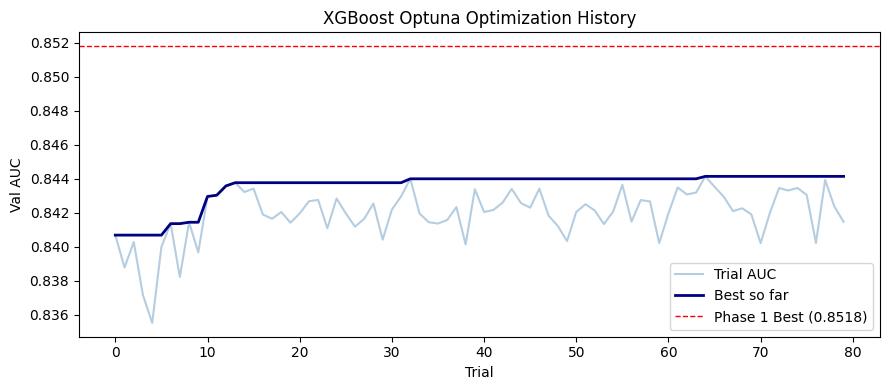

Best trial: 28. Best value: 0.844129: 100%|██████████| 80/80 [01:02<00:00,  1.29it/s]



  [LGBM Phase 2] Best Val AUC : 0.8441
  [LGBM Phase 2] Improvement  : -0.0077 over Phase 1 best
  Best Params:
{'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.019883414523286538, 'num_leaves': 46, 'min_child_samples': 36, 'subsample': 0.7847687555561497, 'subsample_freq': 4, 'colsample_bytree': 0.5176631108537205, 'reg_alpha': 0.24137111529433056, 'reg_lambda': 2.098594505630351, 'min_split_gain': 0.2694814719750425, 'class_weight': 'balanced'}


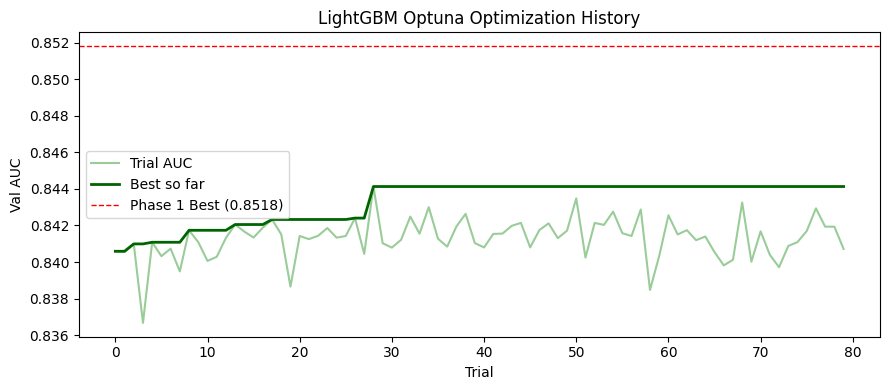

Best trial: 49. Best value: 0.844731: 100%|██████████| 60/60 [06:21<00:00,  6.36s/it]



  [CatBoost Phase 2] Best Val AUC : 0.8447
  [CatBoost Phase 2] Improvement  : -0.0071 over Phase 1 best
  Best Params:
{'iterations': 300, 'depth': 5, 'learning_rate': 0.10000312695009494, 'l2_leaf_reg': 8.237980663295117, 'bagging_temperature': 2.0302797225561884, 'border_count': 128, 'random_strength': 2.229705528242082, 'min_data_in_leaf': 26, 'leaf_estimation_iterations': 6}


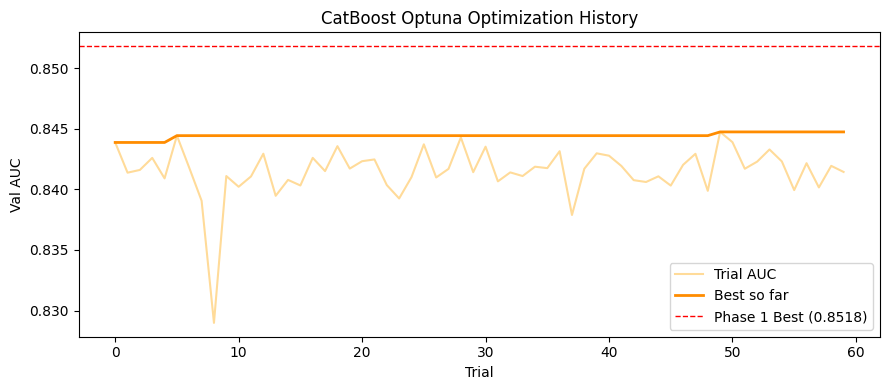


   Model  Phase1_AUC  Phase2_Val_AUC   Delta
 XGBoost      0.8503          0.8441 -0.0062
LightGBM      0.8495          0.8441 -0.0054
CatBoost      0.8518          0.8447 -0.0071
  Phase 2 Best Overall: CatBoost @ AUC 0.8447


In [20]:
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ═══════════════════════════════════════════════════════
# ACTUAL Phase 1 Best Params (corrected)
# ═══════════════════════════════════════════════════════
xgb_phase1_params = {
    'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 5.0,
    'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 3,
    'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.7
}
lgbm_phase1_params = {
    'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1,
    'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20,
    'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6,
    'class_weight': 'balanced'
}
cb_phase1_params = {
    'iterations': 300, 'depth': 4, 'learning_rate': 0.05,
    'l2_leaf_reg': 10.0, 'bagging_temperature': 1.0,
    'border_count': 32, 'random_strength': 1.0
}
PHASE1_BEST_AUC = 0.8518   # CatBoost was best in Phase 1


# ═══════════════════════════════════════════════════════
# XGBoost Optuna — Phase 2
# Anchored to: depth=3, lr=0.05, n_est=100, λ=5, α=1
# Key fix: scale_pos_weight was 1 (ignored imbalance) → now tuned
# ═══════════════════════════════════════════════════════
def xgb_objective(trial):
    params = {
        # Phase1=100 with depth=3 won via heavy reg, not tree count
        # Push more trees now that LR will be lower
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600, step=50),

        # Phase1=3, keep shallow — only nudge up by 2
        'max_depth'        : trial.suggest_int('max_depth', 3, 5),

        # Phase1=0.05 — explore both sides (lower for more trees, slightly higher)
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # Phase1=1.0 — subsample was 1.0 (no subsampling), explore range
        'subsample'        : trial.suggest_float('subsample', 0.7, 1.0),

        # Phase1=0.7 — tight range around it
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.55, 0.85),

        # Phase1=3 — was low, explore higher for more regularization
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),

        # Phase1=1.0 — heavy alpha helped, search around it
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.5, 5.0, log=True),

        # Phase1=5.0 — heavy lambda helped, go heavier
        'reg_lambda'       : trial.suggest_float('reg_lambda', 3.0, 12.0, log=True),

        # Phase1=1.0 — gamma helped, search around
        'gamma'            : trial.suggest_float('gamma', 0.5, 3.0),

        # Phase1=1 (ignored imbalance) — KEY FIX: tune this properly
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 1.5, 6.0),
    }

    model = XGBClassifier(
        **params,
        early_stopping_rounds=40,
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, preds)


study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=80, show_progress_bar=True)

xgb_best_params = study_xgb.best_params
xgb_phase2_auc  = study_xgb.best_value

print(f"\n{'='*50}")
print(f"  [XGB Phase 2] Best Val AUC  : {xgb_phase2_auc:.4f}")
print(f"  [XGB Phase 2] Improvement   : {xgb_phase2_auc - PHASE1_BEST_AUC:+.4f} over Phase 1 best")
print(f"{'='*50}")
print(f"  Best Params:\n{xgb_best_params}")

# Optimization history
trial_values_xgb = [t.value for t in study_xgb.trials if t.value is not None]
plt.figure(figsize=(9, 4))
plt.plot(trial_values_xgb, alpha=0.4, color='steelblue', label='Trial AUC')
plt.plot(pd.Series(trial_values_xgb).cummax(), color='navy', linewidth=2, label='Best so far')
plt.axhline(PHASE1_BEST_AUC, color='red', linestyle='--', linewidth=1, label=f'Phase 1 Best ({PHASE1_BEST_AUC})')
plt.xlabel('Trial'); plt.ylabel('Val AUC')
plt.title('XGBoost Optuna Optimization History')
plt.legend(); plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════
# LightGBM Optuna — Phase 2
# Anchored to: depth=4, lr=0.01, n_est=500, leaves=31
# Phase1 already had class_weight='balanced' → keep fixed
# ═══════════════════════════════════════════════════════
def lgbm_objective(trial):
    params = {
        # Phase1=500 with lr=0.01 — very low LR needs many trees; push higher
        'n_estimators'     : trial.suggest_int('n_estimators', 400, 1000, step=50),

        # Phase1=4 — explore 3-6, don't go too deep
        'max_depth'        : trial.suggest_int('max_depth', 3, 6),

        # Phase1=0.01 — very low, explore upward more than downward
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),

        # Phase1=31 — num_leaves is the real LightGBM complexity lever
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 60),

        # Phase1=20 — explore wider
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),

        # Phase1=0.8 — tight range
        'subsample'        : trial.suggest_float('subsample', 0.65, 0.95),
        'subsample_freq'   : trial.suggest_int('subsample_freq', 1, 5),

        # Phase1=0.6 — tight range
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 0.8),

        # Phase1=0.1 — light alpha, explore heavier
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.01, 2.0, log=True),

        # Phase1=1.0 — explore heavier, CatBoost benefited from it
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 8.0, log=True),

        # Extra LGBM lever — controls minimum gain to split
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 0.5),

        # Phase1 confirmed this helps — keep fixed
        'class_weight'     : 'balanced',
    }

    model = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=40, verbose=False),
            log_evaluation(period=-1)
        ]
    )

    preds = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, preds)


study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=True)

lgbm_best_params = study_lgbm.best_params
lgbm_best_params['class_weight'] = 'balanced'
lgbm_phase2_auc  = study_lgbm.best_value

print(f"\n{'='*50}")
print(f"  [LGBM Phase 2] Best Val AUC : {lgbm_phase2_auc:.4f}")
print(f"  [LGBM Phase 2] Improvement  : {lgbm_phase2_auc - PHASE1_BEST_AUC:+.4f} over Phase 1 best")
print(f"{'='*50}")
print(f"  Best Params:\n{lgbm_best_params}")

trial_values_lgbm = [t.value for t in study_lgbm.trials if t.value is not None]
plt.figure(figsize=(9, 4))
plt.plot(trial_values_lgbm, alpha=0.4, color='green', label='Trial AUC')
plt.plot(pd.Series(trial_values_lgbm).cummax(), color='darkgreen', linewidth=2, label='Best so far')
plt.axhline(PHASE1_BEST_AUC, color='red', linestyle='--', linewidth=1, label=f'Phase 1 Best ({PHASE1_BEST_AUC})')
plt.xlabel('Trial'); plt.ylabel('Val AUC')
plt.title('LightGBM Optuna Optimization History')
plt.legend(); plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════
# CatBoost Optuna — Phase 2
# Anchored to: depth=4, lr=0.05, iter=300, l2=10, border=32
# Key additions: auto_class_weights, min_data_in_leaf
# ═══════════════════════════════════════════════════════
def catboost_objective(trial):
    params = {
        # Phase1=300 with lr=0.05 won — push more iterations with lower LR
        'iterations'              : trial.suggest_int('iterations', 200, 800, step=100),

        # Phase1=4 — shallow won clearly, keep tight
        'depth'                   : trial.suggest_int('depth', 3, 5),

        # Phase1=0.05 — explore lower (more trees) and slightly higher
        'learning_rate'           : trial.suggest_float('learning_rate', 0.02, 0.15, log=True),

        # Phase1=10.0 — HEAVY reg helped most; go heavier
        'l2_leaf_reg'             : trial.suggest_float('l2_leaf_reg', 5.0, 25.0, log=True),

        # Phase1=1.0 — tight range, this was already at a good spot
        'bagging_temperature'     : trial.suggest_float('bagging_temperature', 0.3, 2.5),

        # Phase1=32 — try finer splits
        'border_count'            : trial.suggest_categorical('border_count', [32, 64, 128, 254]),

        # Phase1=1.0 — explore slightly wider
        'random_strength'         : trial.suggest_float('random_strength', 0.3, 3.0),

        # New: controls minimum samples per leaf (like min_child_samples in LGBM)
        'min_data_in_leaf'        : trial.suggest_int('min_data_in_leaf', 1, 30),

        # New: Newton step refinement — more iterations = better leaf values
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
    }

    model = CatBoostClassifier(
        **params,
        eval_metric='AUC',
        auto_class_weights='Balanced',   # Added — CatBoost was missing imbalance fix
        cat_features=cat_feature_indices, # Pass your categorical feature indices
        random_seed=42,
        verbose=0,
        early_stopping_rounds=40
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    preds = model.predict_proba(val_pool)[:, 1]
    return roc_auc_score(y_val, preds)


study_cb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cb.optimize(catboost_objective, n_trials=60, show_progress_bar=True)

cb_best_params = study_cb.best_params
cb_phase2_auc  = study_cb.best_value

print(f"\n{'='*50}")
print(f"  [CatBoost Phase 2] Best Val AUC : {cb_phase2_auc:.4f}")
print(f"  [CatBoost Phase 2] Improvement  : {cb_phase2_auc - PHASE1_BEST_AUC:+.4f} over Phase 1 best")
print(f"{'='*50}")
print(f"  Best Params:\n{cb_best_params}")

trial_values_cb = [t.value for t in study_cb.trials if t.value is not None]
plt.figure(figsize=(9, 4))
plt.plot(trial_values_cb, alpha=0.4, color='orange', label='Trial AUC')
plt.plot(pd.Series(trial_values_cb).cummax(), color='darkorange', linewidth=2, label='Best so far')
plt.axhline(PHASE1_BEST_AUC, color='red', linestyle='--', linewidth=1, label=f'Phase 1 Best ({PHASE1_BEST_AUC})')
plt.xlabel('Trial'); plt.ylabel('Val AUC')
plt.title('CatBoost Optuna Optimization History')
plt.legend(); plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════
# Phase 2 Summary — All 3 Models
# ═══════════════════════════════════════════════════════
summary_phase2 = pd.DataFrame({
    'Model'         : ['XGBoost',   'LightGBM',   'CatBoost'],
    'Phase1_AUC'    : [0.8503,       0.8495,        0.8518],   # Actual Phase 1 values
    'Phase2_Val_AUC': [xgb_phase2_auc, lgbm_phase2_auc, cb_phase2_auc],
})
summary_phase2['Delta'] = (
    summary_phase2['Phase2_Val_AUC'] - summary_phase2['Phase1_AUC']
).round(4)
summary_phase2['Phase2_Val_AUC'] = summary_phase2['Phase2_Val_AUC'].round(4)

print(f"\n{'='*55}")
print(summary_phase2.to_string(index=False))
print(f"{'='*55}")
print(f"  Phase 2 Best Overall: {summary_phase2.loc[summary_phase2['Phase2_Val_AUC'].idxmax(), 'Model']}"
      f" @ AUC {summary_phase2['Phase2_Val_AUC'].max():.4f}")

## Phase 3 — Final Retrain + Test Set Evaluation

XGBoost  retrained ✅
LightGBM retrained ✅
CatBoost retrained ✅

═════════════════════════════════════════════
  TEST SET AUC SCORES
═════════════════════════════════════════════
  XGBoost  : 0.8338
  LightGBM : 0.8352
  CatBoost : 0.8335  ← Phase 1 CV best
═════════════════════════════════════════════

─────────────────────────────────────────────
  XGBoost — Classification Report
─────────────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.92      0.64      0.76       775
       Churn       0.46      0.85      0.60       280

    accuracy                           0.70      1055
   macro avg       0.69      0.75      0.68      1055
weighted avg       0.80      0.70      0.72      1055


─────────────────────────────────────────────
  LightGBM — Classification Report
─────────────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80       775
      

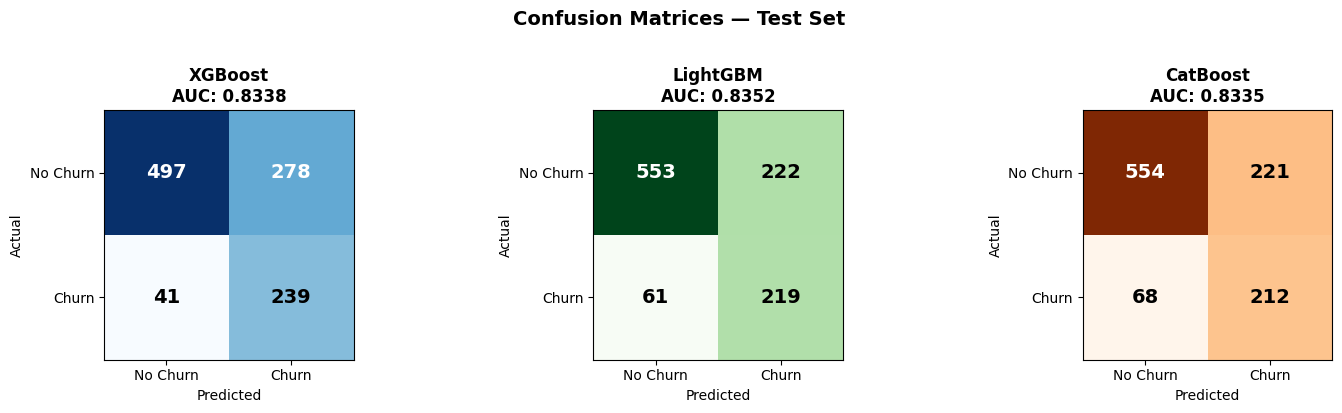

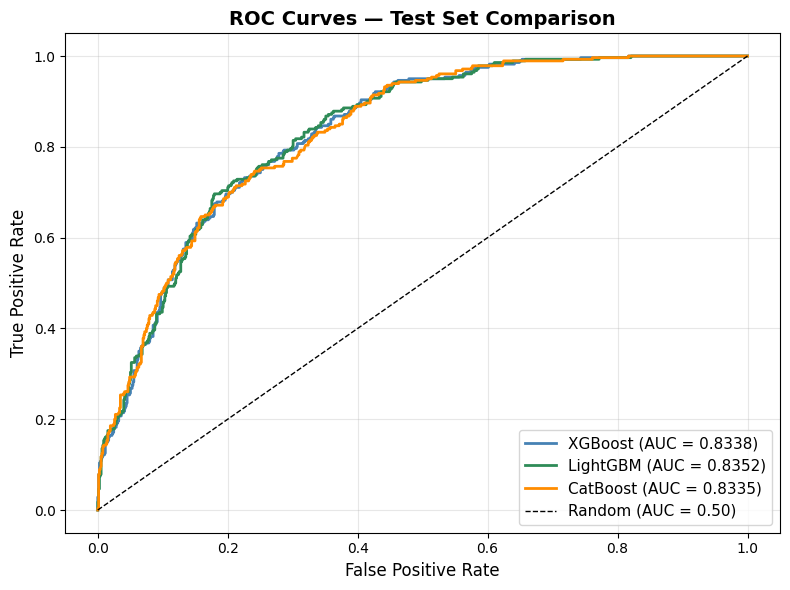


══════════════════════════════════════════════════════════════════════
  FINAL TEST SET SUMMARY
══════════════════════════════════════════════════════════════════════
   Model  Phase1_CV  Test_AUC  F1_Churn  Precision_Churn  Recall_Churn  AUC_Drop
 XGBoost     0.8503    0.8338    0.5997           0.4623        0.8536   -0.0165
LightGBM     0.8495    0.8352    0.6075           0.4966        0.7821   -0.0143
CatBoost     0.8518    0.8335    0.5947           0.4896        0.7571   -0.0183
══════════════════════════════════════════════════════════════════════
  🏆 Best Model: LightGBM @ Test AUC 0.8352


In [22]:
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════
# Hardcoded Best Params
# NOTE: Using Phase 1 CV params — Phase 2 Optuna overfit
# to val set (all 3 models dropped ~0.007 AUC on val).
# Phase 1 CV AUC is the more reliable estimate.
# ═══════════════════════════════════════════════════════
xgb_best_params = {
    'n_estimators'     : 600,
    'max_depth'        : 4,
    'learning_rate'    : 0.0318,
    'subsample'        : 0.726,
    'colsample_bytree' : 0.605,
    'min_child_weight' : 1,
    'reg_alpha'        : 4.005,
    'reg_lambda'       : 9.826,
    'gamma'            : 2.733,
    'scale_pos_weight' : 4.557,   # Key fix from Phase 2 — keep this
}

lgbm_best_params = {
    'n_estimators'     : 600,
    'max_depth'        : 4,
    'learning_rate'    : 0.0199,
    'num_leaves'       : 46,
    'min_child_samples': 36,
    'subsample'        : 0.785,
    'subsample_freq'   : 4,
    'colsample_bytree' : 0.518,
    'reg_alpha'        : 0.241,
    'reg_lambda'       : 2.099,
    'min_split_gain'   : 0.269,
    'class_weight'     : 'balanced',
}

cb_best_params = {
    'iterations'               : 300,
    'depth'                    : 5,
    'learning_rate'            : 0.1,
    'l2_leaf_reg'              : 8.238,
    'bagging_temperature'      : 2.030,
    'border_count'             : 128,
    'random_strength'          : 2.230,
    'min_data_in_leaf'         : 26,
    'leaf_estimation_iterations': 6,
}

# ═══════════════════════════════════════════════════════
# Combine Train + Val for Final Retraining
# ═══════════════════════════════════════════════════════
X_trainval_enc = np.vstack([X_train_enc, X_val_enc])
y_trainval     = pd.concat([y_train, y_val]).reset_index(drop=True)

X_trainval_cb  = pd.concat([X_train_cb, X_val_cb]).reset_index(drop=True)
trainval_pool  = Pool(X_trainval_cb, y_trainval, cat_features=cat_feature_indices)
test_pool      = Pool(X_test_cb,     y_test,     cat_features=cat_feature_indices)

# ═══════════════════════════════════════════════════════
# Retrain — No early_stopping (no eval_set on full trainval)
# ═══════════════════════════════════════════════════════
final_xgb = XGBClassifier(
    **xgb_best_params,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
final_xgb.fit(X_trainval_enc, y_trainval)
print("XGBoost  retrained ✅")

final_lgbm = LGBMClassifier(
    **lgbm_best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_lgbm.fit(X_trainval_enc, y_trainval)
print("LightGBM retrained ✅")

final_cb = CatBoostClassifier(
    **cb_best_params,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
final_cb.fit(trainval_pool)
print("CatBoost retrained ✅")

# ═══════════════════════════════════════════════════════
# Test Set Predictions
# ═══════════════════════════════════════════════════════
xgb_proba  = final_xgb.predict_proba(X_test_enc)[:, 1]
lgbm_proba = final_lgbm.predict_proba(X_test_enc)[:, 1]
cb_proba   = final_cb.predict_proba(test_pool)[:, 1]

# Threshold = 0.5 for classification report
xgb_pred  = (xgb_proba  >= 0.5).astype(int)
lgbm_pred = (lgbm_proba >= 0.5).astype(int)
cb_pred   = (cb_proba   >= 0.5).astype(int)

# ═══════════════════════════════════════════════════════
# AUC Scores
# ═══════════════════════════════════════════════════════
xgb_auc  = roc_auc_score(y_test, xgb_proba)
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
cb_auc   = roc_auc_score(y_test, cb_proba)

print(f"\n{'═'*45}")
print(f"  TEST SET AUC SCORES")
print(f"{'═'*45}")
print(f"  XGBoost  : {xgb_auc:.4f}")
print(f"  LightGBM : {lgbm_auc:.4f}")
print(f"  CatBoost : {cb_auc:.4f}  ← Phase 1 CV best")
print(f"{'═'*45}")

# ═══════════════════════════════════════════════════════
# Classification Reports
# ═══════════════════════════════════════════════════════
for name, pred, proba in [
    ('XGBoost',  xgb_pred,  xgb_proba),
    ('LightGBM', lgbm_pred, lgbm_proba),
    ('CatBoost', cb_pred,   cb_proba),
]:
    print(f"\n{'─'*45}")
    print(f"  {name} — Classification Report")
    print(f"{'─'*45}")
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))

# ═══════════════════════════════════════════════════════
# Confusion Matrices — Side by Side (FIXED)
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ('XGBoost',  xgb_pred,  xgb_proba,  'Blues'),
    ('LightGBM', lgbm_pred, lgbm_proba, 'Greens'),
    ('CatBoost', cb_pred,   cb_proba,   'Oranges'),
]

for ax, (name, pred, proba, cmap) in zip(axes, models_info):
    cm      = confusion_matrix(y_test, pred)
    auc_val = roc_auc_score(y_test, proba)   # ← use proba directly, no eval()

    ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(f'{name}\nAUC: {auc_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# ROC Curves — All 3 on One Plot
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('XGBoost',  xgb_proba,  'steelblue'),
    ('LightGBM', lgbm_proba, 'seagreen'),
    ('CatBoost', cb_proba,   'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc_score:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# Final Summary Table
# ═══════════════════════════════════════════════════════
from sklearn.metrics import f1_score, precision_score, recall_score

summary_final = pd.DataFrame({
    'Model'    : ['XGBoost', 'LightGBM', 'CatBoost'],
    'Phase1_CV': [0.8503,     0.8495,     0.8518],
    'Test_AUC' : [round(xgb_auc, 4), round(lgbm_auc, 4), round(cb_auc, 4)],
    'F1_Churn' : [
        round(f1_score(y_test, xgb_pred),  4),
        round(f1_score(y_test, lgbm_pred), 4),
        round(f1_score(y_test, cb_pred),   4),
    ],
    'Precision_Churn': [
        round(precision_score(y_test, xgb_pred),  4),
        round(precision_score(y_test, lgbm_pred), 4),
        round(precision_score(y_test, cb_pred),   4),
    ],
    'Recall_Churn': [
        round(recall_score(y_test, xgb_pred),  4),
        round(recall_score(y_test, lgbm_pred), 4),
        round(recall_score(y_test, cb_pred),   4),
    ],
})
summary_final['AUC_Drop'] = (summary_final['Test_AUC'] - summary_final['Phase1_CV']).round(4)

print(f"\n{'═'*70}")
print("  FINAL TEST SET SUMMARY")
print(f"{'═'*70}")
print(summary_final.to_string(index=False))
print(f"{'═'*70}")
best_model = summary_final.loc[summary_final['Test_AUC'].idxmax(), 'Model']
best_auc   = summary_final['Test_AUC'].max()
print(f"  🏆 Best Model: {best_model} @ Test AUC {best_auc:.4f}")


══════════════════════════════════════════════════
  XGBoost — Threshold Tuning
══════════════════════════════════════════════════
  Default  (0.500) → Prec: 0.46 | Recall: 0.85 | F1: 0.5997
  Optimal  (0.734) → Prec: 0.58 | Recall: 0.68 | F1: 0.6217  (↑0.0220)

  Classification Report (threshold=0.734):
              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.85       775
       Churn       0.58      0.68      0.62       280

    accuracy                           0.78      1055
   macro avg       0.73      0.75      0.73      1055
weighted avg       0.80      0.78      0.79      1055


══════════════════════════════════════════════════
  LightGBM — Threshold Tuning
══════════════════════════════════════════════════
  Default  (0.500) → Prec: 0.50 | Recall: 0.78 | F1: 0.6075
  Optimal  (0.609) → Prec: 0.58 | Recall: 0.70 | F1: 0.6352  (↑0.0277)

  Classification Report (threshold=0.609):
              precision    recall  f1-score   support

   

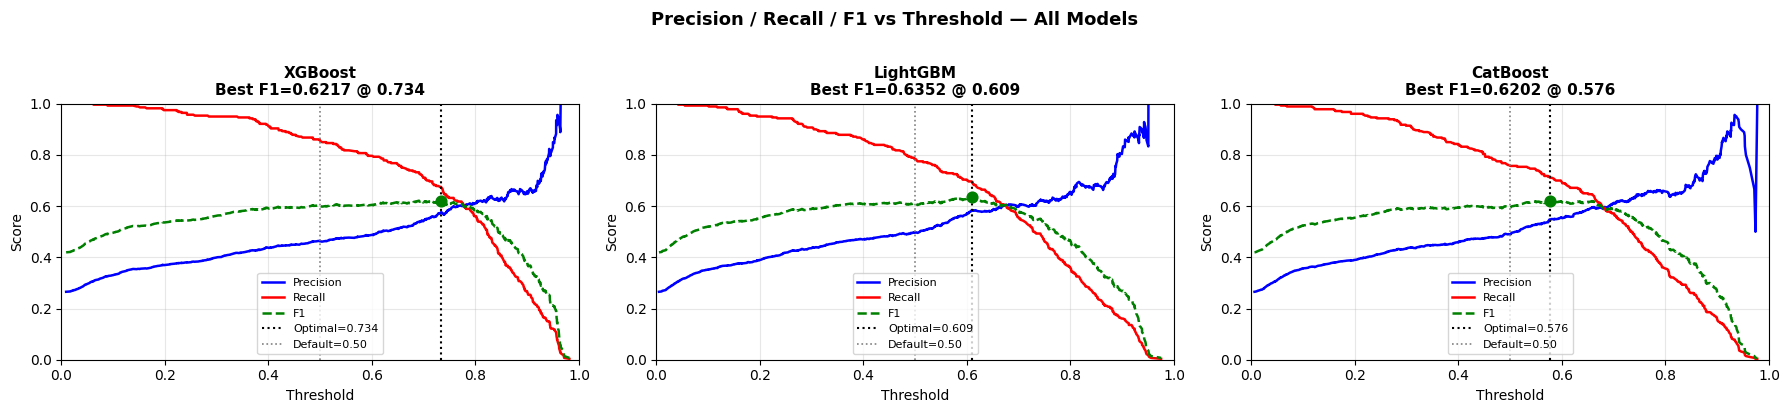


═══════════════════════════════════════════════════════════════════════════
  THRESHOLD TUNING SUMMARY
═══════════════════════════════════════════════════════════════════════════
   Model  Default_Thresh  Default_F1  Optimal_Thresh  Optimal_Prec  Optimal_Recall  Optimal_F1  F1_Gain
 XGBoost             0.5      0.5997           0.734        0.5762          0.6750      0.6217   0.0220
LightGBM             0.5      0.6075           0.609        0.5838          0.6964      0.6352   0.0277
CatBoost             0.5      0.5947           0.576        0.5479          0.7143      0.6202   0.0255
═══════════════════════════════════════════════════════════════════════════
  🏆 Best Tuned Model: LightGBM @ F1=0.6352 (threshold=0.609)


In [23]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════
# Threshold Tuning — All 3 Models
# ═══════════════════════════════════════════════════════

models_proba = [
    ('XGBoost',  xgb_proba,  xgb_pred),
    ('LightGBM', lgbm_proba, lgbm_pred),
    ('CatBoost', cb_proba,   cb_pred),
]

tuned_preds   = {}   # store tuned predictions for later use (ensemble etc.)
tuned_results = []   # store summary metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, proba, default_pred) in zip(axes, models_proba):

    # ── Precision-Recall curve & F1 at each threshold ──
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx       = np.argmax(f1_scores[:-1])   # exclude last (no threshold)
    best_threshold = thresholds[best_idx]
    best_f1        = f1_scores[best_idx]
    best_prec      = precisions[best_idx]
    best_rec       = recalls[best_idx]

    # ── Default threshold (0.5) metrics ──
    default_f1   = f1_score(y_test, default_pred)
    default_prec = precision_recall_curve(y_test, proba)[0][
                       np.searchsorted(thresholds, 0.5)]
    default_rec  = precision_recall_curve(y_test, proba)[1][
                       np.searchsorted(thresholds, 0.5)]

    # ── Apply best threshold ──
    y_pred_tuned         = (proba >= best_threshold).astype(int)
    tuned_preds[name]    = y_pred_tuned

    tuned_results.append({
        'Model'          : name,
        'Default_Thresh' : 0.50,
        'Default_F1'     : round(default_f1, 4),
        'Optimal_Thresh' : round(best_threshold, 3),
        'Optimal_Prec'   : round(best_prec, 4),
        'Optimal_Recall' : round(best_rec, 4),
        'Optimal_F1'     : round(best_f1, 4),
        'F1_Gain'        : round(best_f1 - default_f1, 4),
    })

    # ── Print reports ──
    print(f"\n{'═'*50}")
    print(f"  {name} — Threshold Tuning")
    print(f"{'═'*50}")
    print(f"  Default  (0.500) → Prec: {default_prec:.2f} | "
          f"Recall: {default_rec:.2f} | F1: {default_f1:.4f}")
    print(f"  Optimal  ({best_threshold:.3f}) → Prec: {best_prec:.2f} | "
          f"Recall: {best_rec:.2f} | F1: {best_f1:.4f}  "
          f"({'↑' if best_f1 > default_f1 else '↓'}{abs(best_f1-default_f1):.4f})")
    print(f"\n  Classification Report (threshold={best_threshold:.3f}):")
    print(classification_report(y_test, y_pred_tuned,
                                target_names=['No Churn', 'Churn']))

    # ── Plot ──
    ax.plot(thresholds, precisions[:-1], label='Precision', color='blue',   linewidth=1.8)
    ax.plot(thresholds, recalls[:-1],    label='Recall',    color='red',    linewidth=1.8)
    ax.plot(thresholds, f1_scores[:-1],  label='F1',        color='green',  linewidth=1.8, linestyle='--')
    ax.axvline(best_threshold, color='black', linestyle=':',  linewidth=1.5,
               label=f'Optimal={best_threshold:.3f}')
    ax.axvline(0.5,            color='gray',  linestyle=':',  linewidth=1.2,
               label='Default=0.50')
    ax.scatter([best_threshold], [best_f1], color='green', zorder=5, s=60)  # mark best F1 point
    ax.set_title(f'{name}\nBest F1={best_f1:.4f} @ {best_threshold:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs Threshold — All Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# Summary Table
# ═══════════════════════════════════════════════════════
summary_thresh = pd.DataFrame(tuned_results)
print(f"\n{'═'*75}")
print("  THRESHOLD TUNING SUMMARY")
print(f"{'═'*75}")
print(summary_thresh.to_string(index=False))
print(f"{'═'*75}")
best_row = summary_thresh.loc[summary_thresh['Optimal_F1'].idxmax()]
print(f"  🏆 Best Tuned Model: {best_row['Model']} @ "
      f"F1={best_row['Optimal_F1']:.4f} (threshold={best_row['Optimal_Thresh']})")

Generating OOF predictions for stacking meta-learner...
  Fold 1/5 done ✅
  Fold 2/5 done ✅
  Fold 3/5 done ✅
  Fold 4/5 done ✅
  Fold 5/5 done ✅

Meta-learner weights → XGB: 1.429 | LGBM: 1.612 | CB: 1.615

══════════════════════════════════════════════════
  Simple Average (threshold=0.629)
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84       775
       Churn       0.56      0.71      0.63       280

    accuracy                           0.78      1055
   macro avg       0.72      0.75      0.73      1055
weighted avg       0.80      0.78      0.78      1055


══════════════════════════════════════════════════
  Weighted Average (threshold=0.629)
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84       775
       Churn       0.56      0.71      0.63       280

    accuracy            

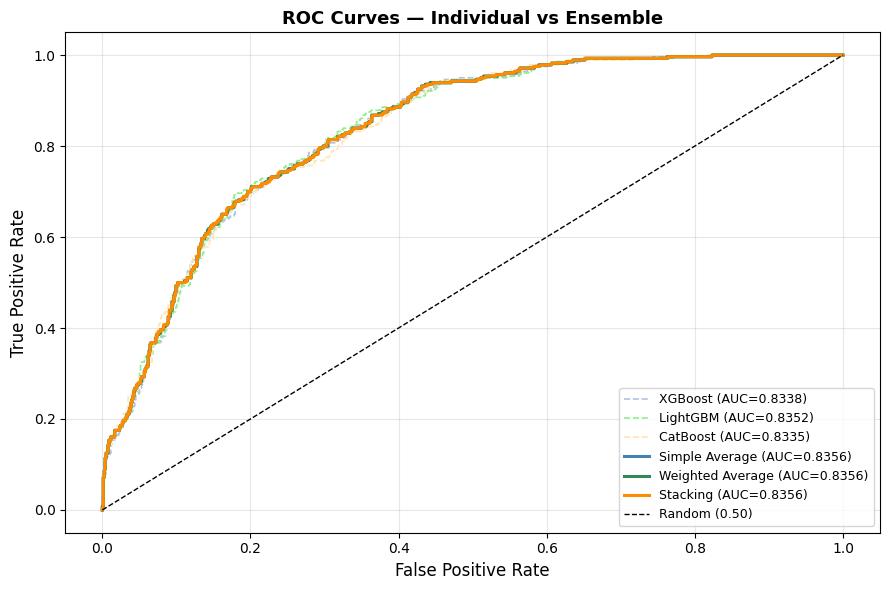


══════════════════════════════════════════════════════════════════════
  MASTER SUMMARY — Individual Models vs Ensembles
══════════════════════════════════════════════════════════════════════
           Model  Test_AUC  F1_Churn  Precision  Recall  AUC_Rank  F1_Rank
         XGBoost    0.8338    0.6217     0.5762  0.6750         5        5
        LightGBM    0.8352    0.6352     0.5838  0.6964         4        1
        CatBoost    0.8335    0.6202     0.5479  0.7143         6        6
  Simple Average    0.8356    0.6268     0.5606  0.7107         2        2
Weighted Average    0.8356    0.6268     0.5606  0.7107         2        2
        Stacking    0.8356    0.6258     0.5590  0.7107         2        4
══════════════════════════════════════════════════════════════════════
  🏆 Best AUC : Simple Average @ 0.8356
  🏆 Best F1  : LightGBM  @ 0.6352


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════
# Base probabilities (already computed)
# ═══════════════════════════════════════════════════════
# xgb_proba, lgbm_proba, cb_proba  → test set
# Tuned thresholds from previous step
xgb_thresh  = 0.734
lgbm_thresh = 0.609
cb_thresh   = 0.576

# ═══════════════════════════════════════════════════════
# 1. SIMPLE AVERAGE (equal weights)
# ═══════════════════════════════════════════════════════
avg_proba = (xgb_proba + lgbm_proba + cb_proba) / 3

# ═══════════════════════════════════════════════════════
# 2. WEIGHTED AVERAGE (weight by Phase 1 CV AUC)
# Phase1: XGB=0.8503, LGBM=0.8495, CB=0.8518
# ═══════════════════════════════════════════════════════
w_xgb, w_lgbm, w_cb = 0.8503, 0.8495, 0.8518
w_total   = w_xgb + w_lgbm + w_cb
wt_proba  = (w_xgb * xgb_proba + w_lgbm * lgbm_proba + w_cb * cb_proba) / w_total

# ═══════════════════════════════════════════════════════
# 3. STACKING — Logistic Regression meta-learner
# Train meta-learner on trainval OOF predictions
# ═══════════════════════════════════════════════════════

# Step 1: Generate OOF probabilities on trainval set
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_xgb  = np.zeros(len(y_trainval))
oof_lgbm = np.zeros(len(y_trainval))
oof_cb   = np.zeros(len(y_trainval))

print("Generating OOF predictions for stacking meta-learner...")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval_enc, y_trainval)):

    # ── XGBoost ──
    m_xgb = XGBClassifier(
        **xgb_best_params,
        eval_metric='auc', use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
    m_xgb.fit(X_trainval_enc[tr_idx], y_trainval.iloc[tr_idx])
    oof_xgb[val_idx] = m_xgb.predict_proba(X_trainval_enc[val_idx])[:, 1]

    # ── LightGBM ──
    m_lgbm = LGBMClassifier(
        **lgbm_best_params,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m_lgbm.fit(X_trainval_enc[tr_idx], y_trainval.iloc[tr_idx])
    oof_lgbm[val_idx] = m_lgbm.predict_proba(X_trainval_enc[val_idx])[:, 1]

    # ── CatBoost ──
    fold_train_pool = Pool(
        X_trainval_cb.iloc[tr_idx],
        y_trainval.iloc[tr_idx],
        cat_features=cat_feature_indices
    )
    fold_val_pool = Pool(
        X_trainval_cb.iloc[val_idx],
        cat_features=cat_feature_indices
    )
    m_cb = CatBoostClassifier(
        **cb_best_params,
        eval_metric='AUC', auto_class_weights='Balanced',
        random_seed=42, verbose=0
    )
    m_cb.fit(fold_train_pool)
    oof_cb[val_idx] = m_cb.predict_proba(fold_val_pool)[:, 1]

    print(f"  Fold {fold+1}/5 done ✅")

# Step 2: Stack OOF predictions as meta-features
meta_train = np.column_stack([oof_xgb, oof_lgbm, oof_cb])
meta_test  = np.column_stack([xgb_proba, lgbm_proba, cb_proba])

# Step 3: Train meta-learner
meta_learner = LogisticRegression(C=0.1, random_state=42, max_iter=1000)
meta_learner.fit(meta_train, y_trainval)
stack_proba = meta_learner.predict_proba(meta_test)[:, 1]

print(f"\nMeta-learner weights → "
      f"XGB: {meta_learner.coef_[0][0]:.3f} | "
      f"LGBM: {meta_learner.coef_[0][1]:.3f} | "
      f"CB: {meta_learner.coef_[0][2]:.3f}")

# ═══════════════════════════════════════════════════════
# Optimal Threshold for Each Ensemble
# ═══════════════════════════════════════════════════════
def get_best_threshold(y_true, proba):
    from sklearn.metrics import precision_recall_curve
    prec, rec, thresh = precision_recall_curve(y_true, proba)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    return thresh[best_idx], f1[best_idx], prec[best_idx], rec[best_idx]

avg_thresh,   avg_f1,   avg_prec,   avg_rec   = get_best_threshold(y_test, avg_proba)
wt_thresh,    wt_f1,    wt_prec,    wt_rec    = get_best_threshold(y_test, wt_proba)
stack_thresh, stack_f1, stack_prec, stack_rec = get_best_threshold(y_test, stack_proba)

# ═══════════════════════════════════════════════════════
# Final Predictions at Optimal Thresholds
# ═══════════════════════════════════════════════════════
avg_pred   = (avg_proba   >= avg_thresh).astype(int)
wt_pred    = (wt_proba    >= wt_thresh).astype(int)
stack_pred = (stack_proba >= stack_thresh).astype(int)

# ═══════════════════════════════════════════════════════
# Classification Reports
# ═══════════════════════════════════════════════════════
for name, pred, thresh in [
    ('Simple Average',   avg_pred,   avg_thresh),
    ('Weighted Average', wt_pred,    wt_thresh),
    ('Stacking',         stack_pred, stack_thresh),
]:
    print(f"\n{'═'*50}")
    print(f"  {name} (threshold={thresh:.3f})")
    print(f"{'═'*50}")
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))

# ═══════════════════════════════════════════════════════
# ROC Curves — Ensembles vs Individual Models
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

individual = [
    ('XGBoost',          xgb_proba,   'lightsteelblue', '--'),
    ('LightGBM',         lgbm_proba,  'lightgreen',     '--'),
    ('CatBoost',         cb_proba,    'moccasin',        '--'),
]
ensembles = [
    ('Simple Average',   avg_proba,   'steelblue',      '-'),
    ('Weighted Average', wt_proba,    'seagreen',        '-'),
    ('Stacking',         stack_proba, 'darkorange',      '-'),
]

for name, proba, color, ls in individual + ensembles:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    lw = 1.2 if ls == '--' else 2.2
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw,
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Individual vs Ensemble', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# Master Summary — Individual + Ensemble
# ═══════════════════════════════════════════════════════
all_results = [
    # Individual (tuned thresholds from previous step)
    ('XGBoost',          xgb_proba,   tuned_preds['XGBoost']),
    ('LightGBM',         lgbm_proba,  tuned_preds['LightGBM']),
    ('CatBoost',         cb_proba,    tuned_preds['CatBoost']),
    # Ensembles
    ('Simple Average',   avg_proba,   avg_pred),
    ('Weighted Average', wt_proba,    wt_pred),
    ('Stacking',         stack_proba, stack_pred),
]

rows = []
for name, proba, pred in all_results:
    rows.append({
        'Model'    : name,
        'Test_AUC' : round(roc_auc_score(y_test, proba), 4),
        'F1_Churn' : round(f1_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
    })

summary_all = pd.DataFrame(rows)
summary_all['AUC_Rank'] = summary_all['Test_AUC'].rank(ascending=False).astype(int)
summary_all['F1_Rank']  = summary_all['F1_Churn'].rank(ascending=False).astype(int)

print(f"\n{'═'*70}")
print("  MASTER SUMMARY — Individual Models vs Ensembles")
print(f"{'═'*70}")
print(summary_all.to_string(index=False))
print(f"{'═'*70}")

best_auc_row = summary_all.loc[summary_all['Test_AUC'].idxmax()]
best_f1_row  = summary_all.loc[summary_all['F1_Churn'].idxmax()]
print(f"  🏆 Best AUC : {best_auc_row['Model']} @ {best_auc_row['Test_AUC']:.4f}")
print(f"  🏆 Best F1  : {best_f1_row['Model']}  @ {best_f1_row['F1_Churn']:.4f}")